# CUAD on GLM-5.2 and Anthropic Opus 4.8 (Eval Protocol)

Barebones benchmark: feed each contract's full text into one prompt, ask one of CUAD's 41 clause questions, grade by **span_recall** (fraction of gold answer spans whose word n-grams appear in the model's answer). No chunking, no judge, no MCP, no docker.

**Prereqs:** Jupyter kernel = conda `cookbook` env; `FIREWORKS_API_KEY` and `ANTHROPIC_API_KEY` in `training/.env`. CUAD is not gated (pulled from GitHub).

In [1]:
# Run once if imports fail (uses the notebook kernel's Python).
import sys
!{sys.executable} -m pip install -q -e "../../.[eval]"

In [2]:
# --- config + imports + env (one cell, barebones) ---
import asyncio
import json
import os
import re
import urllib.request
import zipfile
from pathlib import Path

import litellm
from dotenv import load_dotenv
from eval_protocol.models import EvaluateResult, EvaluationRow
from eval_protocol.pytest import SingleTurnRolloutProcessor
from eval_protocol.pytest.types import RolloutProcessorConfig

FIREWORKS_MODEL = "fireworks_ai/accounts/fireworks/models/glm-5p2"
ANTHROPIC_MODEL = "anthropic/claude-opus-4-8"
MODELS = {"GLM-5.2 (Fireworks)": FIREWORKS_MODEL, "Opus 4.8 (Anthropic)": ANTHROPIC_MODEL}

N_CONTRACTS = 20            # picked evenly across the token-length distribution (1=shortest, 3=short/med/long, ...)
MAX_TOKENS = 128_000
CONCURRENCY = 4
REQUEST_TIMEOUT = 1800
NGRAM_N = 5                # span_recall n-gram window

# LLM judge for answerable rows: neutral third model via OpenRouter. Scores 0 / 0.5 / 1.0
# (total miss / partial hit / complete hit). Impossible rows still use the deterministic
# not-found rule below, so the judge only runs on answerable rows.
JUDGE_MODEL = "openrouter/openai/gpt-5.5"
JUDGE_CONCURRENCY = 8

training_dir = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "training" and (p / "pyproject.toml").exists()),
    Path("../../").resolve(),
)
load_dotenv(training_dir / ".env")
for k in ("FIREWORKS_API_KEY", "ANTHROPIC_API_KEY", "OPENROUTER_API_KEY"):
    if not os.getenv(k):
        raise EnvironmentError(f"Set {k} in {training_dir / '.env'}")

# Opus 4.8 rejects `temperature` (reasoning model); drop_params strips unknowns but
# temperature is "known" to Anthropic and still gets sent -> 400. So we add it per-model below.
litellm.drop_params = True

/opt/homebrew/Caskroom/miniconda/base/envs/cookbook/lib/python3.12/site-packages/eval_protocol/models.py:1156: PydanticDeprecatedSince20: Support for class-based `config` is deprecated, use ConfigDict instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  class TaskDefinitionModel(BaseModel):


In [10]:
# Download CUAD's data.zip from the Atticus Project GitHub (the HF loader script is deprecated),
# parse test.json (SQuAD format), flatten to one row per (contract, question_category).
CUAD_DIR = Path("data") / "cuad"
CUAD_DIR.mkdir(parents=True, exist_ok=True)
CUAD_ZIP = CUAD_DIR / "data.zip"
CUAD_URL = "https://raw.githubusercontent.com/TheAtticusProject/cuad/main/data.zip"

if not CUAD_ZIP.exists():
    print(f"Downloading CUAD from {CUAD_URL} (~18MB)...")
    urllib.request.urlretrieve(CUAD_URL, CUAD_ZIP)

with zipfile.ZipFile(CUAD_ZIP) as zf, zf.open("test.json") as f:
    cuad_raw = json.load(f)

pairs = []  # one dict per (contract, question)
for entry in cuad_raw["data"]:
    title = entry["title"]
    for paragraph in entry["paragraphs"]:
        context = paragraph["context"]
        for qa in paragraph["qas"]:
            pairs.append({
                "title": title,
                "context": context,
                "question": qa["question"],
                "gold_spans": [a["text"] for a in qa["answers"]],
                "is_impossible": qa.get("is_impossible", False),  # No answer exists
            })

print(f"Loaded {len(pairs):,} (contract, question) pairs across "
      f"{len(set(p['title'] for p in pairs))} contracts")

Loaded 4,182 (contract, question) pairs across 102 contracts


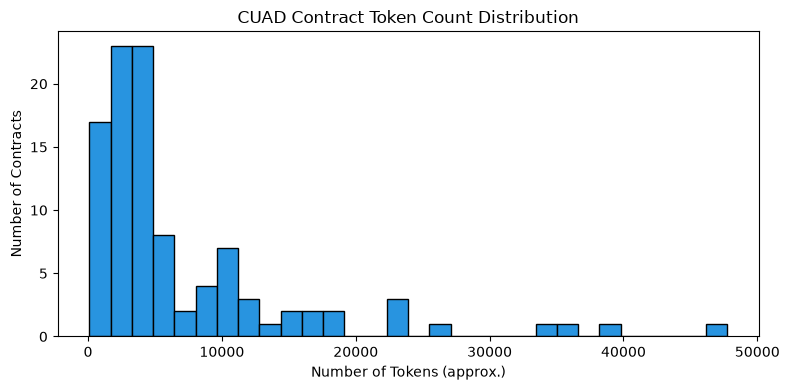

Built 820 rows from 20 contracts:
      109 tokens | 41 questions | RMRGROUPINC_01_22_2020-EX-99.1-JOINT FILING AGREEMENT
      413 tokens | 41 questions | SPIENERGYCO,LTD_07_10_2014-EX-10-Cooperation Agreement of 50
      735 tokens | 41 questions | ThriventVariableInsuranceAccountB_20190701_N-6_EX-99.D(IV)_1
    1,605 tokens | 41 questions | ScansourceInc_20190822_10-K_EX-10.39_11793959_EX-10.39_Distr
    1,911 tokens | 41 questions | ACCELERATEDTECHNOLOGIESHOLDINGCORP_04_24_2003-EX-10.13-JOINT
    2,280 tokens | 41 questions | CENTRACKINTERNATIONALINC_10_29_1999-EX-10.3-WEB SITE HOSTING
    2,694 tokens | 41 questions | PAXMEDICA,INC_07_02_2020-EX-10.12-Master Service Agreement
    2,955 tokens | 41 questions | WEBHELPCOMINC_03_22_2000-EX-10.8-HOSTING AGREEMENT
    3,450 tokens | 41 questions | CYBERIANOUTPOSTINC_07_09_1998-EX-10.13-PROMOTION AGREEMENT
    3,682 tokens | 41 questions | TEARDROPGOLFCO_10_23_1996-EX-10.12-ENDORSEMENT AGREEMENT
    3,945 tokens | 41 questions | LOOKSMA

In [11]:
# Pick N_CONTRACTS contracts evenly across CUAD's token-length distribution.
# N=1 -> shortest contract; N=3 -> short/medium/long; N=6 -> six spread across the range.
# Token estimate via whitespace split (good enough for bucketing; avoids a tiktoken dep).
import matplotlib.pyplot as plt

def n_tokens(text: str) -> int:
    return len(text.split())

by_title = {}
for p in pairs:
    by_title.setdefault(p["title"], p["context"])
contracts = sorted(((n_tokens(ctx), title) for title, ctx in by_title.items()))  # (n_tokens, title), asc

# Show a histogram of contract token length distribution
token_counts = [n_tokens(ctx) for ctx in by_title.values()]
plt.figure(figsize=(8, 4))
plt.hist(token_counts, bins=30, edgecolor="black", color="#2894e0")
plt.title("CUAD Contract Token Count Distribution")
plt.xlabel("Number of Tokens (approx.)")
plt.ylabel("Number of Contracts")
plt.tight_layout()
plt.show()

# Evenly spaced indices over the sorted length distribution.
n_pick = min(N_CONTRACTS, len(contracts))
if n_pick < 1:
    raise ValueError("N_CONTRACTS must be >= 1")
idxs = sorted(set(round(i * (len(contracts) - 1) / (n_pick - 1)) for i in range(n_pick))) if n_pick > 1 else [0]
SELECTED = [contracts[i][1] for i in idxs]

SYSTEM = (
    "You are a legal contract reviewer. Quote the exact contract text relevant to the question. "
    "If nothing applies, respond 'Not found.'"
)

rows = []
q_counter = {}
for title in SELECTED:
    for p in pairs:
        if p["title"] != title:
            continue
        content = f"{SYSTEM}\n\nContract:\n{p['context']}\n\nQuestion: {p['question']}"
        q_counter[title] = q_counter.get(title, 0) + 1
        row = EvaluationRow(
            messages=[{"role": "user", "content": content}],
            ground_truth="\n".join(p["gold_spans"]),
        )
        row.input_metadata.row_id = f"{title}-{q_counter[title]}"
        row.input_metadata.dataset_info = {
            "title": title,
            "question": p["question"],
            "gold_spans": p["gold_spans"],
            "is_impossible": p["is_impossible"],
            "n_tokens": n_tokens(p["context"]),
        }
        rows.append(row)

print(f"Built {len(rows)} rows from {len(SELECTED)} contracts:")
for title in SELECTED:
    n = sum(1 for r in rows if r.input_metadata.dataset_info["title"] == title)
    tok = next(r.input_metadata.dataset_info["n_tokens"] for r in rows if r.input_metadata.dataset_info["title"] == title)
    print(f"  {tok:>7,} tokens | {n} questions | {title[:60]}")

In [5]:
# Grader. CUAD is SQuAD 2.0-style: ~70% of (contract, question) pairs are "is_impossible"
# (that clause category doesn't appear in the contract). We score those separately:
# the model gets full credit for saying "Not found", zero for hallucinating a clause.
# Answerable rows are scored by span_recall (fraction of gold spans surfaced).
def _norm(s: str) -> str:
    return re.sub(r"\s+", " ", s.lower().strip())

def _grams(s: str, n: int) -> set[tuple[str, ...]]:
    words = _norm(s).split()
    if len(words) < n:  # span too short to form an n-gram -> empty set
        return set()
    return {tuple(words[i:i + n]) for i in range(len(words) - n + 1)}

def _span_surfaced(gold: str, model_answer: str, n: int) -> bool:
    """Did the model surface this gold span? Substring first (catches short/verbatim spans),
    then n-gram overlap (catches near-verbatim with light reformatting)."""
    g, m = _norm(gold), _norm(model_answer)
    if not g:
        return False
    if g in m:  # exact substring after normalization -> always counts (handles <5-word spans)
        return True
    gg, mg = _grams(g, n), _grams(m, n)
    return bool(gg and (gg & mg))  # any shared n-gram

def span_recall(model_answer: str, gold_spans: list[str], n: int = NGRAM_N) -> float:
    if not gold_spans:
        return 0.0
    if not _norm(model_answer):
        return 0.0
    return sum(1 for g in gold_spans if _span_surfaced(g, model_answer, n)) / len(gold_spans)

_NOT_FOUND_RE = re.compile(r"not found|no (relevant )?clause|nothing (in )?this contract", re.IGNORECASE)

def model_answer(row: EvaluationRow) -> str:
    return str(row.messages[-1].content) if row.messages else ""

async def grade(row: EvaluationRow) -> EvaluationRow:
    """Grade one row in place (sets row.evaluation_result) and return the row.
    Impossible rows use the deterministic not-found rule; answerable rows call the LLM judge."""
    info = row.input_metadata.dataset_info
    gold = info.get("gold_spans", [])
    ans = model_answer(row)
    if info.get("is_impossible") or not gold:
        # No clause applies. Reward a correct "Not found"; penalize hallucinating one.
        said_not_found = bool(_NOT_FOUND_RE.search(ans)) or len(ans.strip()) < 40
        row.evaluation_result = EvaluateResult(
            score=1.0 if said_not_found else 0.0,
            reason="impossible: said not found" if said_not_found else "impossible: hallucinated",
        )
        return row
    # Answerable: ask the LLM judge for a 0 / 0.5 / 1 score.
    score, raw = await judge_score(info.get("question", ""), gold, ans)
    row.evaluation_result = EvaluateResult(score=score, reason=f"judge={score} ({raw[:20]}) gold_spans={len(gold)}")
    return row

In [6]:
# LLM judge: asks GPT-5 (via OpenRouter) to score the model's answer vs the gold spans
# on a 3-level scale. Replaces span_recall for answerable rows (span_recall was too strict
# to see paraphrase/partial matches). Impossible rows keep the deterministic not-found rule.
_JUDGE_PROMPT = (
    "You are grading a legal-contract QA answer. The question asks the model to quote the "
    "contract text relevant to a clause category. The reference is the gold-standard text a "
    "lawyer highlighted.\n\n"
    "Score the model's answer on how well it surfaces the SAME legal content as the reference:\n"
    "  1 = COMPLETE HIT: the answer quotes (or closely paraphrases) the relevant clause text.\n"
    "  0.5 = PARTIAL HIT: the answer surfaces part of the relevant content, or is correct but "
    "incomplete, or paraphrases the gist without the specific terms.\n"
    "  0 = TOTAL MISS: the answer does not surface the relevant content (wrong text, "
    "hallucination, or unrelated).\n\n"
    "Ignore formatting, ellipses, and extra surrounding text. Focus on whether the legally "
    "relevant content is present. Reply with ONLY one of: 0, 0.5, 1\n\n"
    "Question: {question}\n\n"
    "Reference (gold answer spans, joined):\n{reference}\n\n"
    "Model answer:\n{answer}"
)
_JUDGE_RE = re.compile(r"\b(0(?:\.5)?|1(?:\.0+)?)\b")
_judge_sem = asyncio.Semaphore(JUDGE_CONCURRENCY)


async def judge_score(question: str, gold_spans: list[str], answer: str) -> tuple[float, str]:
    """Return (score, raw_judge_text). Score in {0, 0.5, 1}. Falls back to 0 on parse/error."""
    reference = "\n".join(gold_spans) or "(no reference spans)"
    prompt = _JUDGE_PROMPT.format(
        question=question,
        reference=reference,
        answer=(answer or ""),
    )
    try:
        async with _judge_sem:
            resp = await litellm.acompletion(
                model=JUDGE_MODEL,
                messages=[{"role": "user", "content": prompt}],
                temperature=0.0,
                max_tokens=64,  # GPT-5 reasoning needs room; <50 returns empty content
                timeout=120,
            )
        raw = (resp.choices[0].message.content or "").strip()
    except Exception as e:
        return 0.0, f"judge error: {type(e).__name__}"
    m = _JUDGE_RE.search(raw)
    if not m:
        return 0.0, f"unparsed: {raw[:30]}"
    val = float(m.group(1))
    return (0.0 if val < 0.25 else 0.5 if val < 0.75 else 1.0), raw.strip()

In [7]:
# Run both models over the rows, grade each. Each task is wrapped to return exceptions
# as values (so one timeout doesn't kill the run) while tqdm.gather still shows a progress bar.
from tqdm.auto import tqdm

async def _safe(coro):
    try:
        return await coro
    except Exception as e:
        return e

all_results: dict[str, list[EvaluationRow]] = {}
for label, model in MODELS.items():
    work = [r.model_copy(deep=True) for r in rows]
    completion_params = {"model": model, "max_tokens": MAX_TOKENS, "timeout": REQUEST_TIMEOUT}
    if not model.startswith("anthropic/"):
        completion_params["temperature"] = 0.0

    processor = SingleTurnRolloutProcessor(drop_trailing_assistant_messages=True)
    config = RolloutProcessorConfig(
        completion_params=completion_params,
        mcp_config_path="",
        semaphore=asyncio.Semaphore(CONCURRENCY),
    )
    print(f"\n--- Running {label} ({model}) over {len(work)} rows ---")
    done = await tqdm.gather(*[_safe(c) for c in processor(work, config)], desc=label, total=len(work))
    rows_ok = [r for r in done if isinstance(r, EvaluationRow)]
    dropped = [r for r in done if not isinstance(r, EvaluationRow)]
    for r in dropped:
        print(f"  dropped: {type(r).__name__}: {str(r)[:100]}")
    # grade answerable rows via the LLM judge (async, concurrent); impossible rows are
    # graded deterministically inside grade() and return immediately without a judge call.
    print(f"  grading {len(rows_ok)} rows via {JUDGE_MODEL}...")
    graded = await tqdm.gather(*[grade(r) for r in rows_ok], desc=f"{label} judge", total=len(rows_ok))
    all_results[label] = list(graded)
    scores = [r.evaluation_result.score for r in graded if r.evaluation_result]
    acc = sum(scores) / len(scores) if scores else 0.0
    print(f"  {label}: mean score {acc:.2f} over {len(graded)} rows ({len(dropped)} dropped)")

/opt/homebrew/Caskroom/miniconda/base/envs/cookbook/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



--- Running GLM-5.2 (Fireworks) (fireworks_ai/accounts/fireworks/models/glm-5p2) over 820 rows ---


GLM-5.2 (Fireworks):  91%|█████████ | 743/820 [28:30<12:54, 10.06s/it]


Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.



GLM-5.2 (Fireworks):  96%|█████████▌| 784/820 [40:06<20:15, 33.78s/it]

...

  GLM-5.2 (Fireworks): mean score 0.75 over 814 rows (6 dropped)

--- Running Opus 4.8 (Anthropic) (anthropic/claude-opus-4-8) over 820 rows ---


Opus 4.8 (Anthropic): 100%|██████████| 820/820 [19:29<00:00,  1.43s/it]


  grading 820 rows via openrouter/openai/gpt-5.5...


Opus 4.8 (Anthropic) judge: 100%|██████████| 820/820 [01:45<00:00,  7.78it/s] 

  Opus 4.8 (Anthropic): mean score 0.79 over 820 rows (0 dropped)


In [8]:
# CUAD splits into two row types: answerable (clause exists -> LLM judge 0/0.5/1) and
# impossible (clause absent -> did the model correctly say "Not found"?).
print(f"{'Model':<25} {'Judge score':>12} {'Complete':>9} {'Partial':>9} {'Not-found':>10} {'Overall':>9} {'Drop':>5}")
print("-" * 88)
for label, res in all_results.items():
    ans_scores, imp_scores = [], []
    for r in res:
        if not r.evaluation_result:
            continue
        if r.input_metadata.dataset_info.get("is_impossible") or not r.input_metadata.dataset_info.get("gold_spans"):
            imp_scores.append(r.evaluation_result.score)
        else:
            ans_scores.append(r.evaluation_result.score)
    mean_judge = sum(ans_scores) / len(ans_scores) if ans_scores else 0.0
    complete = sum(1 for s in ans_scores if s == 1.0)
    partial = sum(1 for s in ans_scores if s == 0.5)
    notfound_acc = sum(imp_scores) / len(imp_scores) if imp_scores else 0.0
    overall = sum(ans_scores + imp_scores) / (len(ans_scores) + len(imp_scores)) if (ans_scores or imp_scores) else 0.0
    dropped = len(rows) - len(res)
    print(f"{label:<25} {mean_judge:>12.2f} {complete:>9} {partial:>9} {notfound_acc:>10.1%} {overall:>9.2f} {dropped:>5}")
print("\nJudge score = mean over answerable rows (0=miss, 0.5=partial, 1=complete). Complete/Partial = row counts.")
print("Not-found acc = over impossible rows (1.0 = correctly said Not found, 0.0 = hallucinated).")

Model                      Judge score  Complete   Partial  Not-found   Overall  Drop
----------------------------------------------------------------------------------------
GLM-5.2 (Fireworks)               0.76       182         0      75.0%      0.75     6
Opus 4.8 (Anthropic)              0.73       178         0      80.9%      0.79     0

Judge score = mean over answerable rows (0=miss, 0.5=partial, 1=complete). Complete/Partial = row counts.
Not-found acc = over impossible rows (1.0 = correctly said Not found, 0.0 = hallucinated).


In [9]:
# Per-length-bucket breakdown. Bucket each row by its contract's token count, then show
# judge score (answerable) and not-found acc (impossible) per bucket per model. This is
# where long-context degradation shows up: does the 60k-token bucket score worse than 15k?
def bucket(n_tok: int) -> str:
    if n_tok < 25_000: return "short (<25k)"
    if n_tok < 50_000: return "medium (25-50k)"
    return "long (50k+)"

print(f"{'Model':<23} {'Bucket':<16} {'Judge':>7} {'Comp':>5} {'Part':>5} {'NFound':>8} {'Overall':>9} {'N':>4}")
print("-" * 82)
for label, res in all_results.items():
    by_bucket = {}
    for r in res:
        if not r.evaluation_result:
            continue
        info = r.input_metadata.dataset_info or {}
        b = bucket(info.get("n_tokens", 0))
        by_bucket.setdefault(b, {"ans": [], "imp": [], "complete": 0, "partial": 0})
        impossible = info.get("is_impossible") or not info.get("gold_spans")
        if impossible:
            by_bucket[b]["imp"].append(r.evaluation_result.score)
        else:
            by_bucket[b]["ans"].append(r.evaluation_result.score)
            if r.evaluation_result.score == 1.0: by_bucket[b]["complete"] += 1
            elif r.evaluation_result.score == 0.5: by_bucket[b]["partial"] += 1
    for b in ["short (<25k)", "medium (25-50k)", "long (50k+)"]:
        d = by_bucket.get(b)
        if not d:
            continue
        judge = sum(d["ans"]) / len(d["ans"]) if d["ans"] else float("nan")
        nf = sum(d["imp"]) / len(d["imp"]) if d["imp"] else float("nan")
        all_s = d["ans"] + d["imp"]
        overall = sum(all_s) / len(all_s) if all_s else float("nan")
        n = len(d["ans"]) + len(d["imp"])
        judge_s = f"{judge:.2f}" if judge == judge else "  - "
        nf_s = f"{nf:.0%}" if nf == nf else "  -  "
        ov_s = f"{overall:.2f}" if overall == overall else "  - "
        print(f"{label:<23} {b:<16} {judge_s:>7} {d['complete']:>5} {d['partial']:>5} {nf_s:>8} {ov_s:>9} {n:>4}")
    print()

Model                   Bucket             Judge  Comp  Part   NFound   Overall    N
----------------------------------------------------------------------------------
GLM-5.2 (Fireworks)     short (<25k)        0.80   171     0      75%      0.77  775
GLM-5.2 (Fireworks)     medium (25-50k)     0.41    11     0      58%      0.46   39

Opus 4.8 (Anthropic)    short (<25k)        0.79   169     0      81%      0.80  779
Opus 4.8 (Anthropic)    medium (25-50k)     0.32     9     0      69%      0.44   41

